# 🫀 Notebook 6 — ML Model Training: Clinical Dataset (~1190 rows)
## Cardiovascular Disease Prediction from Clinical Features
### CVD Digital Twin Project | CAD_DT_Final

---

## 📂 I/O Contract
```
CAD_DT_Final/
├── Outputs/Clinical/
│   ├── df_clinical_train.csv    ← INPUT
│   └── df_clinical_test.csv     ← INPUT
└── Outputs/
    ├── Models/
    │   ├── clinical_pipeline.pkl           ← OUTPUT
    │   ├── clinical_model_results.csv      ← OUTPUT
    │   └── clinical_feature_importance.csv ← OUTPUT
    └── Figures/
        ├── clinical_roc_curves.png         ← OUTPUT
        ├── clinical_confusion_matrix.png   ← OUTPUT
        └── clinical_calibration.png        ← OUTPUT
```

## ⚠️ Key design notes
- Clinical dataset ≈ 1190 rows — **high overfitting risk**
- Data arrives **unscaled** from NB2 — scaling happens **inside** pipeline only
- All models: `CalibratedClassifierCV(Pipeline([StandardScaler, clf]), cv=5)`
- GridSearchCV applied to top-2 CV models
- Overfitting flag if `(train_AUC − test_AUC) > 0.08`


---
# Section 1 — Setup & Paths


In [1]:
import os
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.calibration     import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics         import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'xgboost', '-q'], check=True)
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True

# ── Mount Drive ───────────────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print('✅ Google Drive mounted')
except ImportError:
    print('ℹ️  Not in Colab — using local paths')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR     = '/content/drive/MyDrive/CAD_DT_Final/'
CLINICAL_DIR = BASE_DIR + 'Outputs/Clinical/'
MODELS_DIR   = BASE_DIR + 'Outputs/Models/'
FIGURES_DIR  = BASE_DIR + 'Outputs/Figures/'

TRAIN_PATH   = CLINICAL_DIR + 'df_clinical_train.csv'
TEST_PATH    = CLINICAL_DIR + 'df_clinical_test.csv'

PIPELINE_OUT    = MODELS_DIR + 'clinical_pipeline.pkl'
RESULTS_OUT     = MODELS_DIR + 'clinical_model_results.csv'
FEAT_IMP_OUT    = MODELS_DIR + 'clinical_feature_importance.csv'
ROC_FIG_OUT     = FIGURES_DIR + 'clinical_roc_curves.png'
CM_FIG_OUT      = FIGURES_DIR + 'clinical_confusion_matrix.png'
CALIB_FIG_OUT   = FIGURES_DIR + 'clinical_calibration.png'

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

RANDOM_STATE = 42

print('==' * 33)
print('  CVD DIGITAL TWIN — CLINICAL MODEL TRAINING')
print('  NB6 | CAD_DT_Final')
print('==' * 33)
for path, label in [(TRAIN_PATH,'train CSV'), (TEST_PATH,'test CSV')]:
    exists = os.path.isfile(path)
    print(f"  {'✅' if exists else '❌'} {label}: {path}")
    if not exists:
        raise FileNotFoundError(f'Run NB2 first to generate: {path}')
print('\n[SECTION 1 COMPLETE] ✅')


Mounted at /content/drive
✅ Google Drive mounted
  CVD DIGITAL TWIN — CLINICAL MODEL TRAINING
  NB6 | CAD_DT_Final
  ✅ train CSV: /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/df_clinical_train.csv
  ✅ test CSV: /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/df_clinical_test.csv

[SECTION 1 COMPLETE] ✅


---
# Section 2 — Data Loading & Validation

Dataset ≈ 1190 rows. Data arrives **unscaled** from NB2.
Scaling is handled entirely inside each sklearn `Pipeline`.


In [2]:
# print('==' * 33)
# print('  SECTION 2: Data Loading & Validation')
# print('==' * 33)

# df_train = pd.read_csv(TRAIN_PATH)
# df_test  = pd.read_csv(TEST_PATH)

# print(f'\n📊 Shapes — Train: {df_train.shape}  |  Test: {df_test.shape}')

# TARGET_COL = 'target'
# assert TARGET_COL in df_train.columns, f"❌ '{TARGET_COL}' missing from train"
# assert TARGET_COL in df_test.columns,  f"❌ '{TARGET_COL}' missing from test"

# X_train = df_train.drop(columns=[TARGET_COL])
# y_train = df_train[TARGET_COL]
# X_test  = df_test.drop(columns=[TARGET_COL])
# y_test  = df_test[TARGET_COL]

# # Drop accidental index column
# for col in ['index', 'Unnamed: 0']:
#     if col in X_train.columns:
#         X_train = X_train.drop(columns=[col])
#         X_test  = X_test.drop(columns=[col])
#         print(f'⚠️  Dropped column: {col}')

# # ── Column alignment ─────────────────────────────────────────────────────────
# assert list(X_train.columns) == list(X_test.columns), (
#     f'❌ Column mismatch!\nTrain: {list(X_train.columns)}\nTest: {list(X_test.columns)}'
# )
# FEATURE_COLS = X_train.columns.tolist()
# print(f'\n✅ Column alignment confirmed ({len(FEATURE_COLS)} features)')
# print(f'   Features: {FEATURE_COLS}')

# # ── No-object dtype check ─────────────────────────────────────────────────────
# bad = [c for c in X_train.columns if X_train[c].dtype == object]
# assert len(bad) == 0, f'❌ Object dtype columns found: {bad}'
# print('✅ No object/string dtype columns')

# # ── Null check ────────────────────────────────────────────────────────────────
# assert X_train.isnull().sum().sum() == 0, '❌ Nulls in X_train'
# assert X_test.isnull().sum().sum()  == 0, '❌ Nulls in X_test'
# print('✅ No null values')

# # ── Class balance ─────────────────────────────────────────────────────────────
# train_counts = y_train.value_counts().sort_index()
# test_counts  = y_test.value_counts().sort_index()
# imbalance_ratio = train_counts.max() / train_counts.min()

# print(f'\n📊 Class Balance:')
# print(f'   Train → {train_counts.to_dict()}  (imbalance ratio: {imbalance_ratio:.2f})')
# print(f'   Test  → {test_counts.to_dict()}')

# # ── Scale check: data should NOT be pre-scaled ────────────────────────────────
# # Continuous features should have std >> 1 (not StandardScaler output)
# continuous_cols = [c for c in FEATURE_COLS if X_train[c].nunique() > 10]
# if continuous_cols:
#     sample_std = X_train[continuous_cols[0]].std()
#     if sample_std < 2.0:
#         print(f'⚠️  {continuous_cols[0]} std={sample_std:.3f} — data may already be scaled. '
#               'Pipeline scaler will still run correctly but may be a near-identity transform.')
#     else:
#         print(f'✅ Data appears unscaled (e.g. {continuous_cols[0]} std={sample_std:.2f}) — '
#               'scaling handled inside pipeline.')

# print(f'\n[SECTION 2 COMPLETE] ✅ {len(X_train):,} train / {len(X_test):,} test rows ready.')
# #

  SECTION 2: Data Loading & Validation

📊 Shapes — Train: (952, 19)  |  Test: (238, 19)

✅ Column alignment confirmed (18 features)
   Features: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'chest_pain_type_1.0', 'chest_pain_type_2.0', 'chest_pain_type_3.0', 'chest_pain_type_4.0', 'resting_ecg_0.0', 'resting_ecg_1.0', 'resting_ecg_2.0', 'st_slope_1', 'st_slope_2', 'st_slope_3']
✅ No object/string dtype columns
✅ No null values

📊 Class Balance:
   Train → {0: 449, 1: 503}  (imbalance ratio: 1.12)
   Test  → {0: 112, 1: 126}
⚠️  age std=1.001 — data may already be scaled. Pipeline scaler will still run correctly but may be a near-identity transform.

[SECTION 2 COMPLETE] ✅ 952 train / 238 test rows ready.


In [ ]:
# =============================================

In [9]:
print('==' * 33)
print('  DUPLICATE-SECTION 2: Data Loading & Validation')
print('==' * 33)

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

print(f'\n📊 Shapes — Train: {df_train.shape}  |  Test: {df_test.shape}')

TARGET_COL = 'target'
assert TARGET_COL in df_train.columns, f"❌ '{TARGET_COL}' missing from train"
assert TARGET_COL in df_test.columns,  f"❌ '{TARGET_COL}' missing from test"

X_train = df_train.drop(columns=[TARGET_COL])
y_train = df_train[TARGET_COL]
X_test  = df_test.drop(columns=[TARGET_COL])
y_test  = df_test[TARGET_COL]
# ── Drop high-leakage / diagnosis-like features ─────────────
DROP_COLS = [
    'exercise_angina',
    'st_slope_1', 'st_slope_2', 'st_slope_3',
    'chest_pain_type_1.0',
    'chest_pain_type_2.0',
    'chest_pain_type_3.0',
    'chest_pain_type_4.0'
]

X_train = X_train.drop(columns=DROP_COLS, errors='ignore')
X_test  = X_test.drop(columns=DROP_COLS, errors='ignore')

print("\n⚠️ Dropped high-leakage features:")
print(DROP_COLS)

print(f"\nRemaining features ({X_train.shape[1]}):")
print(X_train.columns.tolist())
# Drop accidental index column
for col in ['index', 'Unnamed: 0']:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
        X_test  = X_test.drop(columns=[col])
        print(f'⚠️  Dropped column: {col}')

# ── Column alignment ─────────────────────────────────────────────────────────
assert list(X_train.columns) == list(X_test.columns), (
    f'❌ Column mismatch!\nTrain: {list(X_train.columns)}\nTest: {list(X_test.columns)}'
)
FEATURE_COLS = X_train.columns.tolist()
print(f'\n✅ Column alignment confirmed ({len(FEATURE_COLS)} features)')
print(f'   Features: {FEATURE_COLS}')

# ── No-object dtype check ─────────────────────────────────────────────────────
bad = [c for c in X_train.columns if X_train[c].dtype == object]
assert len(bad) == 0, f'❌ Object dtype columns found: {bad}'
print('✅ No object/string dtype columns')

# ── Null check ────────────────────────────────────────────────────────────────
assert X_train.isnull().sum().sum() == 0, '❌ Nulls in X_train'
assert X_test.isnull().sum().sum()  == 0, '❌ Nulls in X_test'
print('✅ No null values')

# ── Class balance ─────────────────────────────────────────────────────────────
train_counts = y_train.value_counts().sort_index()
test_counts  = y_test.value_counts().sort_index()
imbalance_ratio = train_counts.max() / train_counts.min()

print(f'\n📊 Class Balance:')
print(f'   Train → {train_counts.to_dict()}  (imbalance ratio: {imbalance_ratio:.2f})')
print(f'   Test  → {test_counts.to_dict()}')

# ── Scale check: data should NOT be pre-scaled ────────────────────────────────
# Continuous features should have std >> 1 (not StandardScaler output)
continuous_cols = [c for c in FEATURE_COLS if X_train[c].nunique() > 10]
if continuous_cols:
    sample_std = X_train[continuous_cols[0]].std()
    if sample_std < 2.0:
        print(f'⚠️  {continuous_cols[0]} std={sample_std:.3f} — data may already be scaled. '
              'Pipeline scaler will still run correctly but may be a near-identity transform.')
    else:
        print(f'✅ Data appears unscaled (e.g. {continuous_cols[0]} std={sample_std:.2f}) — '
              'scaling handled inside pipeline.')

print(f'\n[SECTION 2 COMPLETE] ✅ {len(X_train):,} train / {len(X_test):,} test rows ready.')


  DUPLICATE-SECTION 2: Data Loading & Validation

📊 Shapes — Train: (952, 19)  |  Test: (238, 19)

⚠️ Dropped high-leakage features:
['exercise_angina', 'st_slope_1', 'st_slope_2', 'st_slope_3', 'chest_pain_type_1.0', 'chest_pain_type_2.0', 'chest_pain_type_3.0', 'chest_pain_type_4.0']

Remaining features (10):
['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'max_heart_rate', 'oldpeak', 'resting_ecg_0.0', 'resting_ecg_1.0', 'resting_ecg_2.0']

✅ Column alignment confirmed (10 features)
   Features: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'max_heart_rate', 'oldpeak', 'resting_ecg_0.0', 'resting_ecg_1.0', 'resting_ecg_2.0']
✅ No object/string dtype columns
✅ No null values

📊 Class Balance:
   Train → {0: 449, 1: 503}  (imbalance ratio: 1.12)
   Test  → {0: 112, 1: 126}
⚠️  age std=1.001 — data may already be scaled. Pipeline scaler will still run correctly but may be a near-identity transform.

[SECTION 2 COMPLETE] ✅ 952 train / 238 test row

---
# Section 3 — Model Definitions

Every model: `CalibratedClassifierCV(Pipeline([StandardScaler, clf]), method='sigmoid', cv=5)`

- **Logistic Regression** — L2 regularized baseline, `class_weight='balanced'`
- **Random Forest** — regularized for small dataset (shallow, high `min_samples_leaf`)
- **XGBoost** — histogram boosting, `scale_pos_weight` for imbalance
- **Gradient Boosting** — sklearn GBM, conservative depth


In [10]:
print('==' * 33)
print('  SECTION 3: Model Definitions')
print('==' * 33)

pos_weight = float(train_counts[0] / train_counts[1]) if 1 in train_counts.index else 1.0

def make_pipeline(clf):
    """Pipeline([StandardScaler, clf]) — handles raw unscaled input."""
    return Pipeline([('scaler', StandardScaler()), ('clf', clf)])

BASE_MODELS = {
    'Logistic Regression': make_pipeline(
        LogisticRegression(
            C=0.1,                      # stronger L2 for small dataset
            max_iter=2000,
            solver='lbfgs',
            class_weight='balanced',
            random_state=RANDOM_STATE
        )
    ),
    'Random Forest': make_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=6,                # shallow — overfitting guard
            min_samples_leaf=8,         # regularization for small n
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    'XGBoost': make_pipeline(
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,         # slower learning for small dataset
            max_depth=3,                # shallow
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=2.0,             # L2 regularization
            scale_pos_weight=pos_weight,
            tree_method='hist',
            eval_metric='logloss',
            monotone_constraints=(1, 0, 1, 1, 1, -1, 1, 0, 0, 0),
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    'Gradient Boosting': make_pipeline(
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            min_samples_leaf=8,
            subsample=0.8,
            random_state=RANDOM_STATE
        )
    ),
}

print(f'\n📋 {len(BASE_MODELS)} models defined:')
for i, (name, pipe) in enumerate(BASE_MODELS.items(), 1):
    clf_name = type(pipe.named_steps['clf']).__name__
    print(f'  {i}. {name}  →  Pipeline([StandardScaler, {clf_name}])')
print('\n  All will be wrapped: CalibratedClassifierCV(pipeline, method="sigmoid", cv=5)')
print(f'\n[SECTION 3 COMPLETE] ✅')



  SECTION 3: Model Definitions

📋 4 models defined:
  1. Logistic Regression  →  Pipeline([StandardScaler, LogisticRegression])
  2. Random Forest  →  Pipeline([StandardScaler, RandomForestClassifier])
  3. XGBoost  →  Pipeline([StandardScaler, XGBClassifier])
  4. Gradient Boosting  →  Pipeline([StandardScaler, GradientBoostingClassifier])

  All will be wrapped: CalibratedClassifierCV(pipeline, method="sigmoid", cv=5)

[SECTION 3 COMPLETE] ✅


---
# Section 4 — 5-Fold Stratified Cross-Validation

With ≈1190 rows, 5-fold CV gives ~952 train / ~238 test per fold.
We use this for model selection only. The final unbiased estimate comes from the held-out test set.


In [11]:
print('==' * 33)
print('  SECTION 4: 5-Fold Stratified Cross-Validation')
print('==' * 33)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

CV_SCORING = {
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc',
}

cv_results = {}
train_auc_cv = {}   # for overfitting detection

for model_name, pipeline in BASE_MODELS.items():
    t0 = time.time()
    print(f'  [{model_name}] CV...', end=' ', flush=True)

    cv_out = cross_validate(
        estimator=pipeline,
        X=X_train, y=y_train,
        cv=cv_strategy,
        scoring=CV_SCORING,
        n_jobs=-1,
        return_train_score=True   # needed for overfitting check
    )

    elapsed = time.time() - t0
    print(f'done in {elapsed:.1f}s')

    cv_results[model_name] = {
        'CV_Accuracy_mean' : cv_out['test_accuracy'].mean(),
        'CV_Accuracy_std'  : cv_out['test_accuracy'].std(),
        'CV_Precision_mean': cv_out['test_precision'].mean(),
        'CV_Precision_std' : cv_out['test_precision'].std(),
        'CV_Recall_mean'   : cv_out['test_recall'].mean(),
        'CV_Recall_std'    : cv_out['test_recall'].std(),
        'CV_F1_mean'       : cv_out['test_f1'].mean(),
        'CV_F1_std'        : cv_out['test_f1'].std(),
        'CV_AUC_mean'      : cv_out['test_roc_auc'].mean(),
        'CV_AUC_std'       : cv_out['test_roc_auc'].std(),
    }
    train_auc_cv[model_name] = cv_out['train_roc_auc'].mean()

cv_results_df = (
    pd.DataFrame(cv_results).T
    .reset_index().rename(columns={'index': 'Model'})
)

print(f'\n{"=" * 65}')
print('  CROSS-VALIDATION RESULTS (mean ± std, 5 folds)')
print(f'{"=" * 65}')
display_cols = ['Model','CV_Accuracy_mean','CV_Precision_mean','CV_Recall_mean',
                'CV_F1_mean','CV_AUC_mean']
print(cv_results_df[display_cols].round(4).to_string(index=False))

print('\n  AUC stability (std < 0.05 = acceptable for small dataset):')
for _, row in cv_results_df.iterrows():
    stab = '✅ OK' if row['CV_AUC_std'] < 0.05 else '⚠️ VARIABLE'
    train_auc = train_auc_cv[row['Model']]
    gap = train_auc - row['CV_AUC_mean']
    overfit = '⚠️  OVERFIT WARNING' if gap > 0.08 else '✅ OK'
    print(f"  {row['Model']:<25} CV AUC={row['CV_AUC_mean']:.4f}±{row['CV_AUC_std']:.4f}  "
          f"TrainAUC={train_auc:.4f}  Gap={gap:+.4f}  {overfit}  Stab={stab}")

best_cv_model = cv_results_df.loc[cv_results_df['CV_AUC_mean'].idxmax(), 'Model']
best_cv_auc   = cv_results_df['CV_AUC_mean'].max()

# Top-2 models for GridSearchCV
top2_models = cv_results_df.nlargest(2, 'CV_AUC_mean')['Model'].tolist()

print(f'\n  🏆 Best CV model : {best_cv_model} (AUC={best_cv_auc:.4f})')
print(f'  📌 Top-2 for GridSearch: {top2_models}')
print(f'\n[SECTION 4 COMPLETE] ✅')


  SECTION 4: 5-Fold Stratified Cross-Validation
  [Logistic Regression] CV... done in 2.6s
  [Random Forest] CV... done in 4.1s
  [XGBoost] CV... done in 0.5s
  [Gradient Boosting] CV... done in 1.8s

  CROSS-VALIDATION RESULTS (mean ± std, 5 folds)
              Model  CV_Accuracy_mean  CV_Precision_mean  CV_Recall_mean  CV_F1_mean  CV_AUC_mean
Logistic Regression            0.7773             0.8023          0.7714      0.7860       0.8476
      Random Forest            0.7825             0.8107          0.7693      0.7893       0.8684
            XGBoost            0.7983             0.8201          0.7932      0.8062       0.8798
  Gradient Boosting            0.8004             0.8101          0.8132      0.8116       0.8791

  AUC stability (std < 0.05 = acceptable for small dataset):
  Logistic Regression       CV AUC=0.8476±0.0333  TrainAUC=0.8539  Gap=+0.0063  ✅ OK  Stab=✅ OK
  Random Forest             CV AUC=0.8684±0.0274  TrainAUC=0.9289  Gap=+0.0605  ✅ OK  Stab=✅ OK
  XGBo

---
# Section 4b — GridSearchCV on Top-2 Models

Applied to the top-2 CV models to tune key regularization parameters.
Grid is conservative to avoid overfitting on ≈1190 rows.


In [12]:
print('==' * 33)
print('  SECTION 4b: GridSearchCV — Top-2 Models')
print('==' * 33)

PARAM_GRIDS = {
    'Logistic Regression': {
        'clf__C': [0.01, 0.05, 0.1, 0.5, 1.0]
    },
    'Random Forest': {
        'clf__max_depth'       : [4, 6, 8],
        'clf__min_samples_leaf': [4, 8, 16],
    },
    'XGBoost': {
        'clf__max_depth'   : [3, 4],
        'clf__learning_rate': [0.03, 0.05, 0.1],
        'clf__reg_lambda'  : [1.0, 2.0, 5.0],
    },
    'Gradient Boosting': {
        'clf__max_depth'        : [2, 3],
        'clf__min_samples_leaf' : [8, 16],
        'clf__learning_rate'    : [0.03, 0.05],
    },
}

tuned_pipelines = {}  # name -> best pipeline from GridSearch

for model_name in top2_models:
    if model_name not in PARAM_GRIDS:
        print(f'  ⚠️  No param grid for {model_name} — using default pipeline.')
        tuned_pipelines[model_name] = BASE_MODELS[model_name]
        continue

    t0 = time.time()
    print(f'  GridSearch: {model_name}...', end=' ', flush=True)

    gs = GridSearchCV(
        estimator=BASE_MODELS[model_name],
        param_grid=PARAM_GRIDS[model_name],
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring='roc_auc',
        n_jobs=-1,
        refit=True
    )
    gs.fit(X_train, y_train)
    elapsed = time.time() - t0

    print(f'done in {elapsed:.1f}s')
    print(f'    Best params : {gs.best_params_}')
    print(f'    Best CV AUC : {gs.best_score_:.4f}')

    tuned_pipelines[model_name] = gs.best_estimator_

# Fill remaining models with base pipelines (not in top-2)
for model_name, pipeline in BASE_MODELS.items():
    if model_name not in tuned_pipelines:
        tuned_pipelines[model_name] = pipeline

print(f'\n  Tuned pipelines ready: {list(tuned_pipelines.keys())}')
print(f'\n[SECTION 4b COMPLETE] ✅')


  SECTION 4b: GridSearchCV — Top-2 Models
  GridSearch: XGBoost... done in 6.7s
    Best params : {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__reg_lambda': 2.0}
    Best CV AUC : 0.8956
  GridSearch: Gradient Boosting... done in 19.7s
    Best params : {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__min_samples_leaf': 8}
    Best CV AUC : 0.8791

  Tuned pipelines ready: ['XGBoost', 'Gradient Boosting', 'Logistic Regression', 'Random Forest']

[SECTION 4b COMPLETE] ✅


---
# Section 5 — Final Evaluation on Held-Out Test Set

Each tuned pipeline is wrapped in `CalibratedClassifierCV(cv=5)` — **no `prefit`**.
Calibration is learned on training data cross-validation folds.
Both `Test_AUC` and `Test_Brier` are reported.


  SECTION 5: Final Evaluation — Held-Out Test Set
  Fitting + calibrating: XGBoost... done (3.3s) — AUC=0.8845  Brier=0.1341  Gap=+0.1143 ⚠️ OVERFIT
  Fitting + calibrating: Gradient Boosting... done (2.4s) — AUC=0.8753  Brier=0.1421  Gap=+0.0854 ⚠️ OVERFIT
  Fitting + calibrating: Logistic Regression... done (0.1s) — AUC=0.8533  Brier=0.1568  Gap=+0.0001 ✅
  Fitting + calibrating: Random Forest... done (5.4s) — AUC=0.8601  Brier=0.1530  Gap=+0.0615 ✅

  TEST SET RESULTS
              Model  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_AUC  Test_Brier  Train_AUC  AUC_Gap
            XGBoost         0.8235          0.8387       0.8254   0.8320    0.8845      0.1341     0.9988   0.1143
  Gradient Boosting         0.7899          0.8065       0.7937   0.8000    0.8753      0.1421     0.9607   0.0854
Logistic Regression         0.7689          0.7886       0.7698   0.7791    0.8533      0.1568     0.8534   0.0001
      Random Forest         0.7857          0.8151       0.7698 

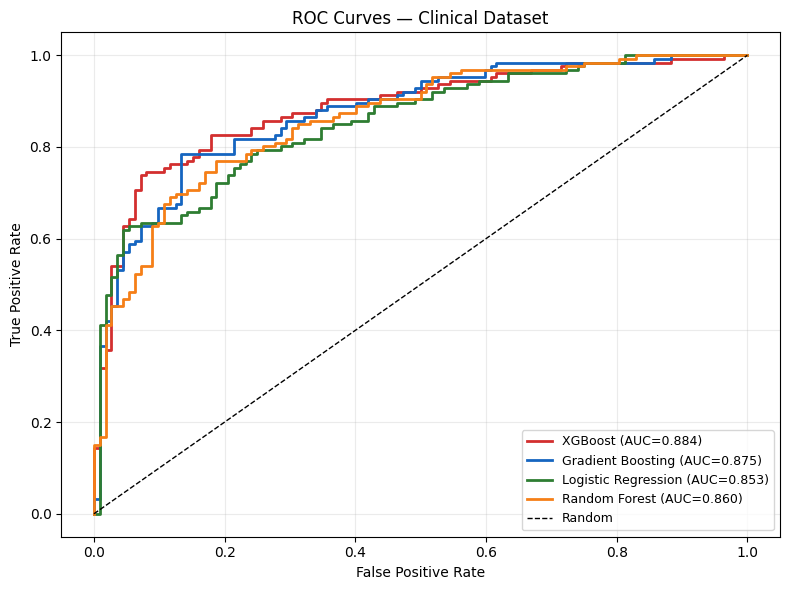

✅ ROC curves saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/clinical_roc_curves.png


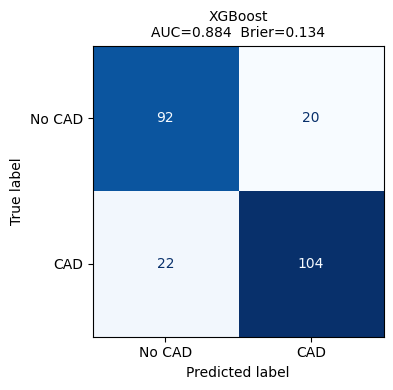

✅ Confusion matrix saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/clinical_confusion_matrix.png


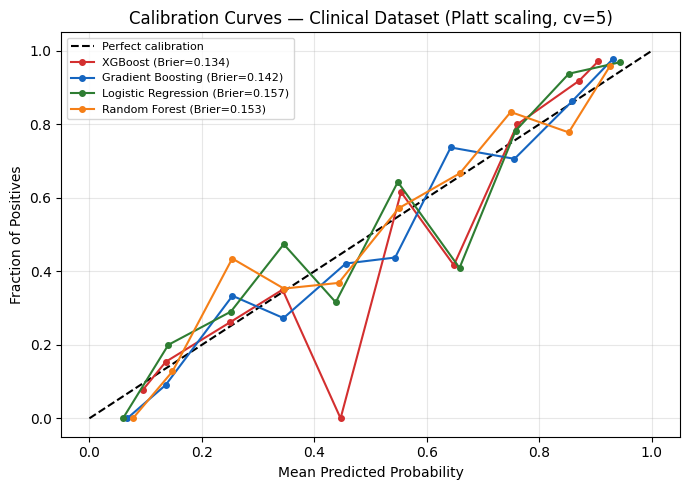

✅ Calibration curves saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/clinical_calibration.png

[SECTION 5 COMPLETE] ✅


In [13]:
print('==' * 33)
print('  SECTION 5: Final Evaluation — Held-Out Test Set')
print('==' * 33)

test_results  = {}
y_pred_all    = {}
y_proba_all   = {}
roc_data_all  = {}
cm_data_all   = {}
fitted_models = {}

for model_name, pipeline in tuned_pipelines.items():
    t0 = time.time()
    print(f'  Fitting + calibrating: {model_name}...', end=' ', flush=True)

    calibrated = CalibratedClassifierCV(
        estimator=pipeline,
        method='sigmoid',
        cv=5
    )
    calibrated.fit(X_train, y_train)
    fitted_models[model_name] = calibrated

    y_proba = calibrated.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    y_pred_all[model_name]  = y_pred
    y_proba_all[model_name] = y_proba

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, zero_division=0)
    rec   = recall_score(y_test, y_pred, zero_division=0)
    f1    = f1_score(y_test, y_pred, zero_division=0)
    Test_AUC   = roc_auc_score(y_test, y_proba)
    Test_Brier = brier_score_loss(y_test, y_proba)

    # Overfitting detection
    train_proba = calibrated.predict_proba(X_train)[:, 1]
    train_auc   = roc_auc_score(y_train, train_proba)
    auc_gap     = train_auc - Test_AUC

    test_results[model_name] = {
        'Test_Accuracy' : acc,
        'Test_Precision': prec,
        'Test_Recall'   : rec,
        'Test_F1'       : f1,
        'Test_AUC'      : Test_AUC,
        'Test_Brier'    : Test_Brier,
        'Train_AUC'     : train_auc,
        'AUC_Gap'       : auc_gap,
    }

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data_all[model_name] = (fpr, tpr, Test_AUC)
    cm_data_all[model_name]  = confusion_matrix(y_test, y_pred)

    elapsed = time.time() - t0
    overfit_flag = '⚠️ OVERFIT' if auc_gap > 0.08 else '✅'
    print(f'done ({elapsed:.1f}s) — AUC={Test_AUC:.4f}  Brier={Test_Brier:.4f}  '
          f'Gap={auc_gap:+.4f} {overfit_flag}')

test_results_df = (
    pd.DataFrame(test_results).T
    .reset_index().rename(columns={'index': 'Model'})
)

print(f'\n{"=" * 65}')
print('  TEST SET RESULTS')
print(f'{"=" * 65}')
print(test_results_df.round(4).to_string(index=False))

# Brier assessment
print('\n  ── Calibration (Brier Score) ──')
for _, row in test_results_df.iterrows():
    b = row['Test_Brier']
    r = '✅ GOOD' if b < 0.10 else '✅ ACCEPTABLE' if b < 0.15 else '⚠️ POOR' if b < 0.20 else '❌'
    print(f"  {row['Model']:<25} Brier={b:.4f}  {r}")

BEST_MODEL_NAME = test_results_df.loc[test_results_df['Test_AUC'].idxmax(), 'Model']
BEST_AUC        = test_results_df['Test_AUC'].max()
BEST_BRIER      = test_results_df.loc[test_results_df['Test_AUC'].idxmax(), 'Test_Brier']

print(f'\n  🏆 Best model: {BEST_MODEL_NAME} (Test_AUC={BEST_AUC:.4f}, Test_Brier={BEST_BRIER:.4f})')

# ── ROC curves ───────────────────────────────────────────────────────────────
ROC_COLORS = ['#d32f2f','#1565C0','#2E7D32','#F57F17']
fig, ax = plt.subplots(figsize=(8, 6))
for (mname, (fpr, tpr, auc_val)), color in zip(roc_data_all.items(), ROC_COLORS):
    ax.plot(fpr, tpr, label=f'{mname} (AUC={auc_val:.3f})', color=color, linewidth=2)
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Clinical Dataset'); ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(ROC_FIG_OUT, dpi=300, bbox_inches='tight'); plt.show()
print(f'✅ ROC curves saved: {ROC_FIG_OUT}')

# ── Confusion matrix (best model only) ───────────────────────────────────────
fig, ax2 = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    cm_data_all[BEST_MODEL_NAME], display_labels=['No CAD','CAD']
).plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title(f'{BEST_MODEL_NAME}\nAUC={BEST_AUC:.3f}  Brier={BEST_BRIER:.3f}', fontsize=10)
plt.tight_layout(); plt.savefig(CM_FIG_OUT, dpi=300, bbox_inches='tight'); plt.show()
print(f'✅ Confusion matrix saved: {CM_FIG_OUT}')

# ── Calibration curves ────────────────────────────────────────────────────────
fig, ax3 = plt.subplots(figsize=(7, 5))
ax3.plot([0,1],[0,1],'k--', label='Perfect calibration')
for (mname, y_proba_m), color in zip(y_proba_all.items(), ROC_COLORS):
    try:
        fp, mp = calibration_curve(y_test, y_proba_m, n_bins=10)
        ax3.plot(mp, fp, label=f'{mname} (Brier={test_results[mname]["Test_Brier"]:.3f})',
                 color=color, linewidth=1.5, marker='o', markersize=4)
    except Exception as e:
        print(f'  ⚠️ Calibration plot failed for {mname}: {e}')
ax3.set_xlabel('Mean Predicted Probability'); ax3.set_ylabel('Fraction of Positives')
ax3.set_title('Calibration Curves — Clinical Dataset (Platt scaling, cv=5)')
ax3.legend(loc='upper left', fontsize=8); ax3.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(CALIB_FIG_OUT, dpi=300, bbox_inches='tight'); plt.show()
print(f'✅ Calibration curves saved: {CALIB_FIG_OUT}')

print(f'\n[SECTION 5 COMPLETE] ✅')


---
# Section 6 — Best Model Selection, Feature Importance & Save

Saves ONE object: `clinical_pipeline.pkl`
= `CalibratedClassifierCV(Pipeline([StandardScaler, best_clf]), method='sigmoid', cv=5)`

NB7 usage: `pipeline.predict_proba(X_raw_clinical)[:, 1]`


  SECTION 6: Best Model Selection, Feature Importance & Save

  🏆 Selected  : XGBoost
  📊 Test_AUC  : 0.8845
  📊 Test_Brier: 0.1341
  ✅ predict_proba verified: shape=(3, 2)
  ✅ Saved & verified: /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/clinical_pipeline.pkl
     Type: CalibratedClassifierCV(Pipeline([StandardScaler, XGBoost]))

📋 Classification Report — XGBoost:
              precision    recall  f1-score   support

      No CAD       0.81      0.82      0.81       112
         CAD       0.84      0.83      0.83       126

    accuracy                           0.82       238
   macro avg       0.82      0.82      0.82       238
weighted avg       0.82      0.82      0.82       238

  ── Feature Importance ──

📊 Top 10 Features (Gini/Gain Impurity Decrease (XGBClassifier)):
            Feature  Importance  Importance_normalized
                sex    0.238355               0.238355
            oldpeak    0.178742               0.178742
fasting_blood_sugar    0.119972         

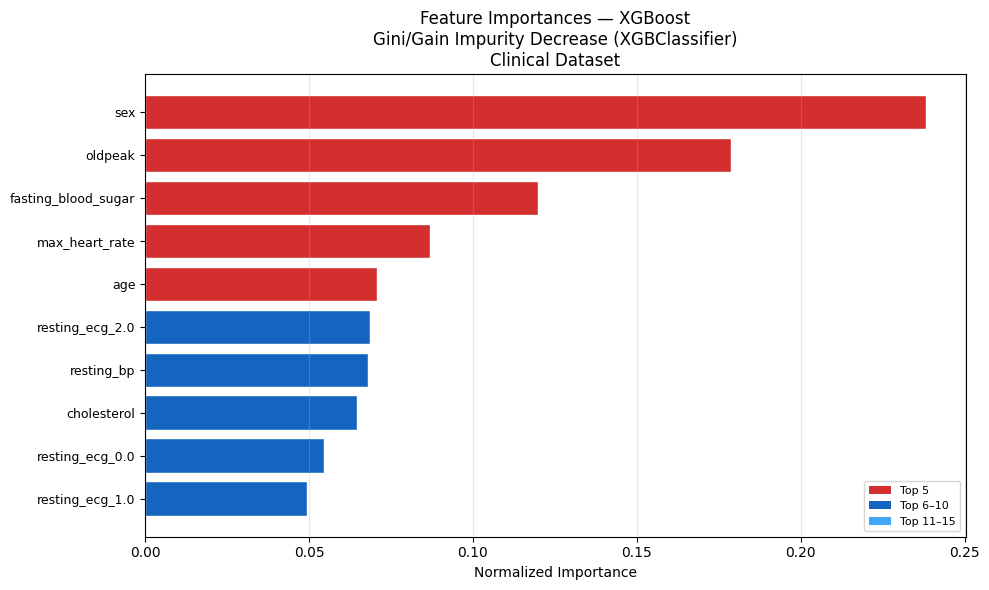

✅ Feature importance figure: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/clinical_feature_importance.png
✅ Feature importance CSV   : /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/clinical_feature_importance.csv
✅ Model results saved      : /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/clinical_model_results.csv

  ── Overfitting Summary ──
  Logistic Regression       CV AUC=0.8476  Test_AUC=0.8533  Gap=0.0057  ✅ OK
  Random Forest             CV AUC=0.8684  Test_AUC=0.8601  Gap=0.0083  ✅ OK
  XGBoost                   CV AUC=0.8798  Test_AUC=0.8845  Gap=0.0047  ✅ OK
  Gradient Boosting         CV AUC=0.8791  Test_AUC=0.8753  Gap=0.0038  ✅ OK

  ✅ NOTEBOOK 6 COMPLETE — Clinical Model Training
  Best model  : XGBoost
  Test_AUC    : 0.8845
  Test_Brier  : 0.1341
  Features    : 10
  Train rows  : 952
  Test rows   : 238

  📁 /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/clinical_pipeline.pkl
  📁 /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/clinical_model_res

In [16]:
print('==' * 33)
print('  SECTION 6: Best Model Selection, Feature Importance & Save')
print('==' * 33)

best_fitted = fitted_models[BEST_MODEL_NAME]

print(f'\n  🏆 Selected  : {BEST_MODEL_NAME}')
print(f'  📊 Test_AUC  : {BEST_AUC:.4f}')
print(f'  📊 Test_Brier: {BEST_BRIER:.4f}')

# ── Verify predict_proba works on raw input ───────────────────────────────────
test_proba = best_fitted.predict_proba(X_test[:3])
assert test_proba.shape == (3, 2), f'❌ predict_proba shape mismatch: {test_proba.shape}'
print(f'  ✅ predict_proba verified: shape={test_proba.shape}')

# ── Save pipeline ────────────────────────────────────────────────────────────
with open(PIPELINE_OUT, 'wb') as f:
    pickle.dump(best_fitted, f)

with open(PIPELINE_OUT, 'rb') as f:
    reload_check = pickle.load(f)
_ = reload_check.predict_proba(X_test[:3])
print(f'  ✅ Saved & verified: {PIPELINE_OUT}')
print(f'     Type: {type(reload_check).__name__}(Pipeline([StandardScaler, {BEST_MODEL_NAME}]))')

# ── Full classification report ───────────────────────────────────────────────
print(f'\n📋 Classification Report — {BEST_MODEL_NAME}:')
print(classification_report(y_test, y_pred_all[BEST_MODEL_NAME], target_names=['No CAD','CAD']))

# ── Feature importance ────────────────────────────────────────────────────────
print('  ── Feature Importance ──')

TREE_BASED = ['Random Forest', 'XGBoost', 'Gradient Boosting']
LINEAR     = ['Logistic Regression']

importances = None
importance_std = None
importance_method = None

def get_inner_clf(calibrated_model):
    """Extract clf from CalibratedClassifierCV(Pipeline([scaler, clf]))."""
    inner_pipe = calibrated_model.calibrated_classifiers_[0].estimator
    return inner_pipe.named_steps['clf']

inner_clf = get_inner_clf(best_fitted)

if BEST_MODEL_NAME in TREE_BASED:
    importances = inner_clf.feature_importances_
    importance_method = f'Gini/Gain Impurity Decrease ({type(inner_clf).__name__})'
elif BEST_MODEL_NAME in LINEAR:
    coef = inner_clf.coef_
    importances = np.abs(coef[0] if coef.ndim > 1 else coef)
    importance_method = f'|Coefficient| ({type(inner_clf).__name__}, standardized)'
else:
    print('  Computing permutation importance...')
    importance_method = 'Permutation (AUC drop, 10 repeats)'
    perm = permutation_importance(
        best_fitted, X_test, y_test,
        scoring='roc_auc', n_repeats=10,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    importances    = perm.importances_mean
    importance_std = perm.importances_std

feat_imp_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': importances,
    'Method'    : importance_method,
    'Model'     : BEST_MODEL_NAME,
})
if importance_std is not None:
    feat_imp_df['Importance_std'] = importance_std

feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)
imp_sum = feat_imp_df['Importance'].sum()
feat_imp_df['Importance_normalized'] = (
    feat_imp_df['Importance'] / imp_sum if imp_sum > 0 else feat_imp_df['Importance']
)

TOP_N = min(15, len(feat_imp_df))
print(f'\n📊 Top {TOP_N} Features ({importance_method}):')
print(feat_imp_df.head(TOP_N)[['Feature','Importance','Importance_normalized']].round(6).to_string(index=False))

# Clinical validation hint
top3 = feat_imp_df.head(3)['Feature'].tolist()
clinical_expected = {'resting_bp','cholesterol','max_heart_rate','age','chest_pain_type'}
top3_clinical = [f for f in top3 if f in clinical_expected]
if top3_clinical:
    print(f'\n  ✅ Clinical features in top 3: {top3_clinical}')
else:
    print(f'  ℹ️  Top 3: {top3} — verify feature names match NB2 output')

# Feature importance bar chart
top_f      = feat_imp_df.head(TOP_N)
bar_colors = ['#d32f2f' if i < 5 else '#1565C0' if i < 10 else '#42A5F5' for i in range(TOP_N)]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(TOP_N), top_f['Importance_normalized'].values, color=bar_colors, edgecolor='white')
ax.set_yticks(range(TOP_N)); ax.set_yticklabels(top_f['Feature'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Normalized Importance')
ax.set_title(f'Feature Importances — {BEST_MODEL_NAME}\n{importance_method}\nClinical Dataset')
ax.grid(axis='x', alpha=0.3)
legend_elements = [
    mpatches.Patch(facecolor='#d32f2f', label='Top 5'),
    mpatches.Patch(facecolor='#1565C0', label='Top 6–10'),
    mpatches.Patch(facecolor='#42A5F5', label='Top 11–15'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
plt.tight_layout()
feat_imp_fig = FIGURES_DIR + 'clinical_feature_importance.png'
plt.savefig(feat_imp_fig, dpi=300, bbox_inches='tight'); plt.show()
print(f'✅ Feature importance figure: {feat_imp_fig}')

feat_imp_df.to_csv(FEAT_IMP_OUT, index=False)
print(f'✅ Feature importance CSV   : {FEAT_IMP_OUT}')

# ── Combined CV + test results ────────────────────────────────────────────────
combined = cv_results_df.merge(test_results_df, on='Model', how='left')
combined['CV_vs_Test_gap'] = (combined['CV_AUC_mean'] - combined['Test_AUC']).abs()
combined['Overfit_flag']   = combined['CV_vs_Test_gap'].apply(
    lambda x: '⚠️ Check' if x > 0.08 else '✅ OK'
)
combined.to_csv(RESULTS_OUT, index=False)
print(f'✅ Model results saved      : {RESULTS_OUT}')

print(f'\n  ── Overfitting Summary ──')
for _, row in combined.iterrows():
    print(f"  {row['Model']:<25} CV AUC={row['CV_AUC_mean']:.4f}  "
          f"Test_AUC={row['Test_AUC']:.4f}  Gap={row['CV_vs_Test_gap']:.4f}  {row['Overfit_flag']}")

print()
print('==' * 33)
print('  ✅ NOTEBOOK 6 COMPLETE — Clinical Model Training')
print('==' * 33)
print(f'  Best model  : {BEST_MODEL_NAME}')
print(f'  Test_AUC    : {BEST_AUC:.4f}')
print(f'  Test_Brier  : {BEST_BRIER:.4f}')
print(f'  Features    : {len(FEATURE_COLS)}')
print(f'  Train rows  : {len(X_train):,}')
print(f'  Test rows   : {len(X_test):,}')
print()
print(f'  📁 {PIPELINE_OUT}')
print(f'  📁 {RESULTS_OUT}')
print(f'  📁 {FEAT_IMP_OUT}')
print(f'  📁 {ROC_FIG_OUT}')
print(f'  📁 {CM_FIG_OUT}')
print(f'  📁 {CALIB_FIG_OUT}')
print()
print('  ⚠️ NB7 USAGE:')
print('     import pickle')
print('     with open("clinical_pipeline.pkl","rb") as f: pipe = pickle.load(f)')
print('     proba = pipe.predict_proba(X_raw_clinical)[:, 1]')
print('==' * 33)


In [15]:
print(X_train.columns)

Index(['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_blood_sugar',
       'max_heart_rate', 'oldpeak', 'resting_ecg_0.0', 'resting_ecg_1.0',
       'resting_ecg_2.0'],
      dtype='object')
